In [1]:
import os
import sys
import numpy as np

# 当前 notebook 所在目录，也就是你的项目主文件夹：
# e:\matlab_script\bci_platform
package_root = os.getcwd()

# package_root 的上一级目录：
# e:\matlab_script
# 这样 Python 才能识别 bci_platform 这个包
package_parent = os.path.dirname(package_root)

if package_parent not in sys.path:
    sys.path.insert(0, package_parent)


from bci_platform.io.edf_bdf_reader import EDFBDFReader
from bci_platform.process.basic_data_process import (
    print_eeg_data_info,
    basic_filter_pipeline,
    segment_by_fixed_window,
    segment_by_marker,
    compute_amplitude_spectrum,
    compute_power_spectrum,
    find_top_frequencies,
    compute_common_band_powers,
)

# 数据文件在项目主文件夹里面的 data 文件夹
file_path = os.path.join(package_root, "data", "S001R01.edf")
reader = EDFBDFReader(file_path)
eeg = reader.read(preload=True, physical=True)

print("\n读取完成")
print("数据 shape:", eeg.data.shape)
print("采样率:", eeg.main_sampling_rate)
print("通道数量:", len(eeg.channel_names))
print("前10个通道:", eeg.channel_names[:10])


读取完成
数据 shape: (65, 9760)
采样率: 160.0
通道数量: 65
前10个通道: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..']


In [2]:
fs = eeg.main_sampling_rate

# 前64个通道是EEG，第65个是EDF Annotations，不作为脑电信号处理
eeg_data = eeg.data[:64, :]

print("EEG数据 shape:", eeg_data.shape)
print("采样率:", fs)

print_eeg_data_info(eeg_data, name="Raw EEG Data")

EEG数据 shape: (64, 9760)
采样率: 160.0
========== Raw EEG Data ==========
shape: (64, 9760)
ndim: 2
dtype: float64
has_nan: False
has_inf: False
min: -518.0
max: 597.0
mean: -1.022624231557377
std: 58.70412765224043


In [3]:
filtered_data = basic_filter_pipeline(
    eeg_data,
    fs,
    low_freq=0.5,
    high_freq=40.0,
    notch_freq=50.0,
    notch_bandwidth=2.0,
    do_detrend=True,
)

print("滤波完成")
print("滤波后数据 shape:", filtered_data.shape)

print_eeg_data_info(filtered_data, name="Filtered EEG Data")

滤波完成
滤波后数据 shape: (64, 9760)
========== Filtered EEG Data ==========
shape: (64, 9760)
ndim: 2
dtype: float64
has_nan: False
has_inf: False
min: -416.22136958206784
max: 629.9012579602658
mean: -3.312468696422598e-17
std: 45.722056463623396


In [4]:
epochs, start_samples = segment_by_fixed_window(
    filtered_data,
    fs,
    window_time=2.0,
    step_time=2.0,
)

print("固定窗分段完成")
print("epochs shape:", epochs.shape)
print("前10段起始采样点:", start_samples[:10])

固定窗分段完成
epochs shape: (30, 64, 320)
前10段起始采样点: [   0  320  640  960 1280 1600 1920 2240 2560 2880]


In [5]:
marker_data = eeg.data[-1, :]

marker_epochs, marker_labels, marker_samples = segment_by_marker(
    filtered_data,
    marker_data,
    fs,
    pre_time=0.0,
    post_time=2.0,
)

print("Marker分段结果")
print("marker_epochs shape:", marker_epochs.shape)
print("marker_labels 前10个:", marker_labels[:10])
print("marker_samples 前10个:", marker_samples[:10])

Marker分段结果
marker_epochs shape: (62, 64, 320)
marker_labels 前10个: [12331 12587 12843 13099 13355 13611 13867 14123 14379 14635]
marker_samples 前10个: [  0  80 160 240 320 400 480 560 640 720]


e:\matlab_script\bci_platform\process\basic_data_process.py:390: RuntimeWarning: invalid value encountered in cast
  marker_int = np.round(marker_data).astype(int)


In [6]:
ch_idx = 0
channel_name = eeg.channel_names[ch_idx]

start_time = 0
duration = 10

start_sample = int(start_time * fs)
end_sample = int((start_time + duration) * fs)

raw_signal = eeg_data[ch_idx, start_sample:end_sample]
filtered_signal = filtered_data[ch_idx, start_sample:end_sample]

freqs, amp = compute_amplitude_spectrum(filtered_signal, fs)

top_freqs, top_values = find_top_frequencies(
    freqs,
    amp,
    fmin=0.5,
    fmax=40.0,
    top_n=10,
)

print("分析通道:", channel_name)
print("分析时间:", start_time, "~", start_time + duration, "s")
print("采样点数:", len(filtered_signal))
print("频率分辨率:", freqs[1] - freqs[0], "Hz")

print("\n0.5~40 Hz 幅值最大的10个频率：")
for f, v in zip(top_freqs, top_values):
    print(f"{f:.2f} Hz, amplitude = {v:.6f}")

分析通道: Fc5.
分析时间: 0 ~ 10 s
采样点数: 1600
频率分辨率: 0.1 Hz

0.5~40 Hz 幅值最大的10个频率：
1.30 Hz, amplitude = 6.467029
0.60 Hz, amplitude = 6.400726
1.10 Hz, amplitude = 6.013595
2.50 Hz, amplitude = 5.807932
1.40 Hz, amplitude = 5.527840
1.50 Hz, amplitude = 4.829277
1.00 Hz, amplitude = 4.701627
0.50 Hz, amplitude = 4.544797
4.50 Hz, amplitude = 4.519542
0.70 Hz, amplitude = 4.214474


In [7]:
band_powers = compute_common_band_powers(filtered_signal, fs)

print("常见频段能量：")
for band_name, value in band_powers.items():
    print(f"{band_name}: {value:.6f}")

常见频段能量：
delta_0.5_4: 43.514493
theta_4_8: 16.106112
alpha_8_13: 9.733343
beta_13_30: 8.619641
gamma_30_40: 2.599802


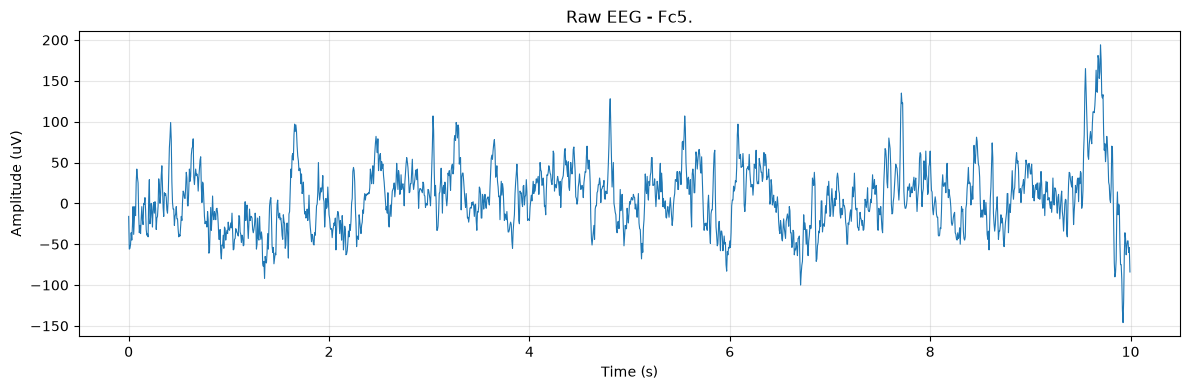

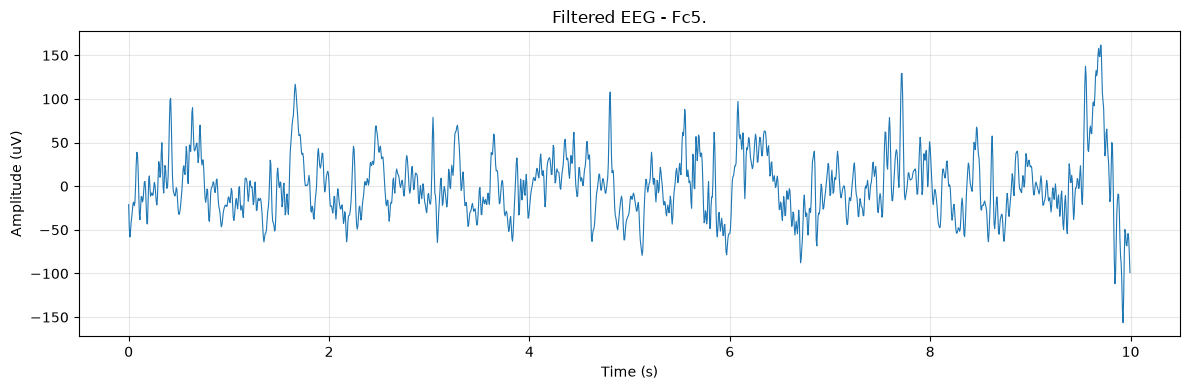

In [8]:
import matplotlib.pyplot as plt

t = np.arange(len(raw_signal)) / fs + start_time

plt.figure(figsize=(12, 4))
plt.plot(t, raw_signal, linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")
plt.title(f"Raw EEG - {channel_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, filtered_signal, linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")
plt.title(f"Filtered EEG - {channel_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

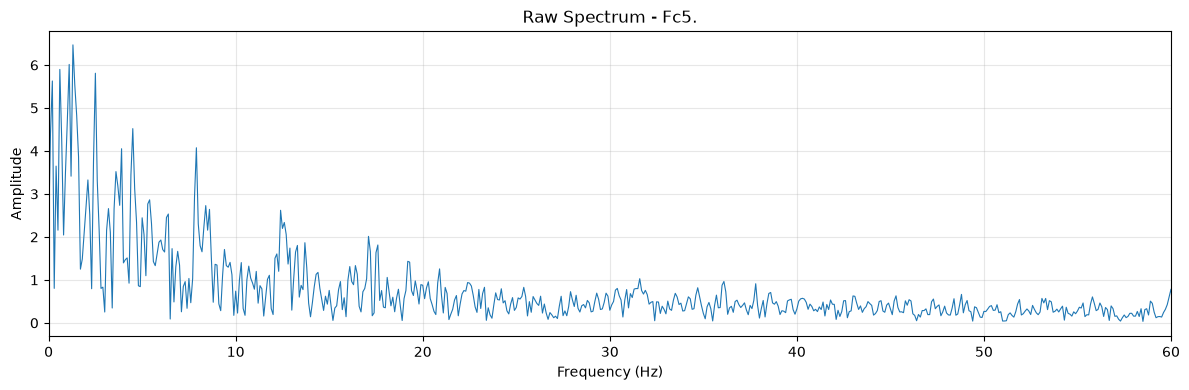

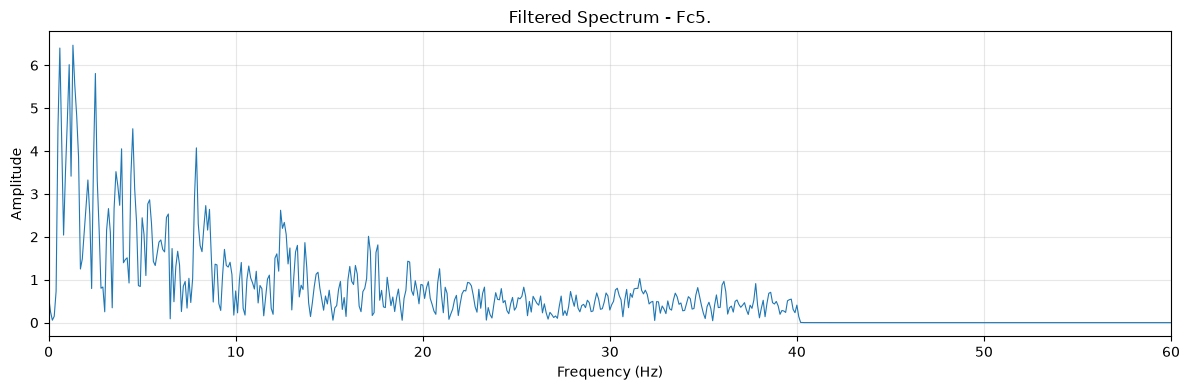

In [9]:
raw_freqs, raw_amp = compute_amplitude_spectrum(raw_signal, fs)
filtered_freqs, filtered_amp = compute_amplitude_spectrum(filtered_signal, fs)

plt.figure(figsize=(12, 4))
plt.plot(raw_freqs, raw_amp, linewidth=0.8)
plt.xlim(0, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title(f"Raw Spectrum - {channel_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(filtered_freqs, filtered_amp, linewidth=0.8)
plt.xlim(0, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title(f"Filtered Spectrum - {channel_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import os
import sys
import numpy as np

# 项目根目录
project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from bci_platform.io.edf_bdf_reader import EDFBDFReader
from bci_platform.process.basic_data_process import basic_filter_pipeline
from bci_platform.process.brain_connectivity import (
    compute_correlation_matrix,
    compute_band_correlation,
    threshold_matrix,
    plot_brain_connectivity
)

In [11]:
file_path = os.path.join(project_root, "data", "S001R01.edf")

reader = EDFBDFReader(file_path)
eeg = reader.read(preload=True, physical=True)

print("数据读取完成")
print("shape:", eeg.data.shape)
print("fs:", eeg.main_sampling_rate)

eeg_data = eeg.data[:64, :]
channel_names = eeg.channel_names[:64]
fs = eeg.main_sampling_rate

数据读取完成
shape: (65, 9760)
fs: 160.0


In [12]:
corr_matrix = compute_correlation_matrix(eeg_data)
alpha_matrix = compute_band_correlation(
    eeg_data,
    fs,
    band=(8, 13)
)
alpha_net = threshold_matrix(alpha_matrix, threshold=0.4)

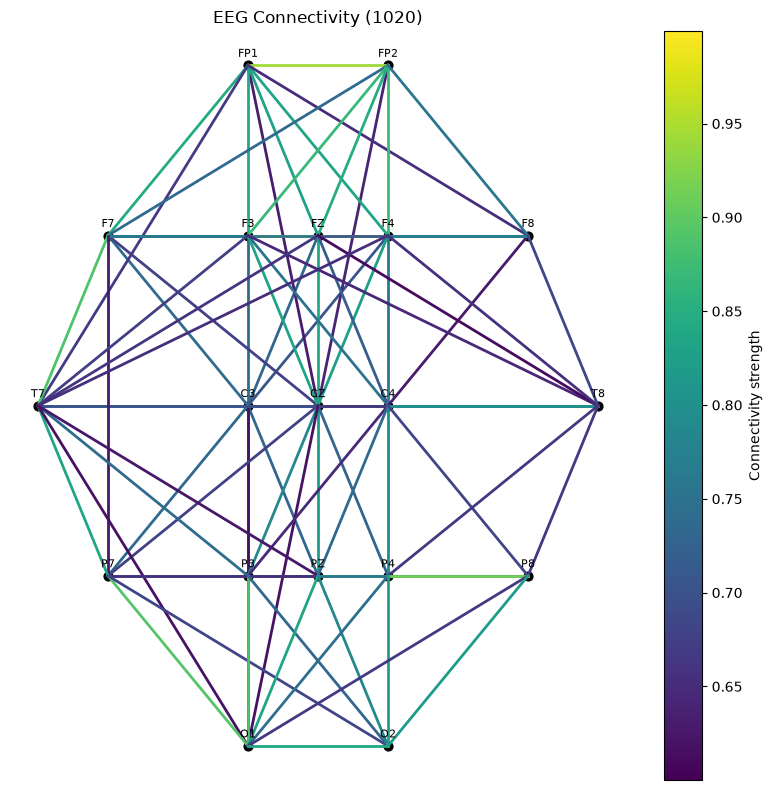

In [17]:
plot_brain_connectivity(
    alpha_net,
    channel_names,
    min_threshold=0.6,
    max_threshold=1.0,
    show_weight=False
)